# Парсинг драгметаллов

Для драг. металлов и валюты:
- engine: `currency`
- market: `selt`
- board: `cets`

Тикеры драгметаллов и валюты можно найти здесь: `https://iss.moex.com/iss/engines/currency/markets/selt/boards/CETS/securities`




In [98]:
from enum import Enum, IntEnum
from aiomoex import get_board_candles
import asyncio
import aiohttp
from datetime import datetime, timedelta, date
import pandas as pd


class Engines(Enum):
    """https://iss.moex.com/iss/engines"""

    STOCK = "stock"  # Фондовый рынок и рынок депозитов
    STATE = "state"  # Рынок ГЦБ (размещение)
    CURRENCY = "currency"  # Валютный рынок
    FUTURES = "futures"  # stockСрочный рынок
    COMMODITY = "commodity"  # Товарный рынок
    INTERVENTIONS = "interventions"  # Товарные интервенции
    OFFBOARD = "offboard"  # ОТС-система
    AGR = "agro"  # Агро
    OTC = "otc"  # ОТС с ЦК
    QUOTES = "quotes"  # Квоты
    MONEY = "money"  # Денежный рынок


class Markets(Enum):
    """https://iss.moex.com/iss/engines/<engine>/markets"""

    # engine=currency
    OTCINDICES = "otcindices"  # Внебиржевые индексы
    SELT = "selt"  # Биржевые сделки с ЦК
    FUTURES = "futures"  # Поставочные фьючерсы
    INDEX = "index"  # Валютный фиксинг
    OTC = "otc"  # Внебиржевой
    
    # engine=futures
    FORTS = "forts"  # Фьючерсы
    OPTIONS = "options"  # Опционы
    FORTSIQS = "fortsiqs"  # Фьючерсы IQS
    OPTIONSIQS = "optionsiqs"  # Опционы IQS
    MAIN = "main"  # Срочные инструменты


class Boards(Enum):
    """https://iss.moex.com/iss/engines/<engine>/markets/<market>/boards"""

    # engine=currency, market=selt
    TQBR = "TQBR"  # Фондовый рынок
    AUCB = "AUCB"  # Аукцион ЦБР - адрес.
    CETS = "CETS"  # Системные сделки - безадрес.
    CNGD = "CNGD"  # Внесистемные сделки- адрес.
    CURR = "CURR"  # Дневная сессия
    FIXN = "FIXN"  # Фиксинг внесистемный- адрес.
    FIXS = "FIXS"  # Фиксинг системный - безадрес.
    LICU = "LICU"  # Внесистемные сделки урегулирования - безадрес.
    SDBP = "SDBP"  # Крупные сделки - безадрес.
    SPEC = "SPEC"  # Поставка - безадресные
    WAPN = "WAPN"  # Внесистемные средневзвешенные - адрес.
    WAPS = "WAPS"  # Системные средневзвешенные - безадрес.

    # engine=futures, market=forts
    RFUD = "RFUD"  # Фьючерсы

class IntervalEnum(IntEnum):
    MINUTE = 1
    TEN_MINUTES = 10
    HOUR = 60
    DAY = 24
    WEEK = 7
    MONTH = 31


# объявим аннотацию для удобства
StockData = list[dict[str, str | int | float]]


async def fetch_ticker_data(
    session: aiohttp.ClientSession,
    ticker: str,
    interval: IntervalEnum,
    start_date: str,
    end_date: str,
    board: Boards,
    engine: Engines,
    market: Markets,
) -> dict[str, StockData]:
    """Функция получает данные о торгах по заданному тикеру с *start_date* по *end_date* с интервалом *interval*, возвращая словарь, где ключом является тикер, а значением - данные

    Args:
        session (aiohttp.ClientSession): aiottp сессия для отпаравки запросов
        ticker (str): Имя тикера
        interval (IntervalEnum): Одно из доступных значений для интервала времени
        start_date (str): Начальная дата в формате yyyy-mm-dd
        end_date (str): Конечная дата в формате yyyy-mm-dd

    Returns:
        dict[str, list[dict[str, str | int | float]]]: Словарь, где ключ - тикер, а значение - данные, например {'SBER': sber_data}
    """
    try:
        # получаем данные по переданному тикеру за указанный период
        res = await get_board_candles(
            session,
            ticker,
            interval,
            start_date,
            end_date,
            board=board.value,
            market=market.value,
            engine=engine.value,
        )
        return {ticker: res}
    except Exception as e:
        print(f"Ошибка парсинга. Не удалось получить данные для {ticker}: {e}")
        print(f"Тип ошибки: {type(e).__name__}")
        return {ticker: []}


async def get_moex_data(
    tickers: list[str],
    start_date: datetime,
    end_date: datetime = datetime.now(),
    interval: IntervalEnum = IntervalEnum.DAY,
    engine: Engines = Engines.CURRENCY,
    market: Markets = Markets.SELT,
    board: Boards = Boards.CETS,
) -> dict[str, StockData]:
    if interval not in IntervalEnum:
        raise ValueError(f"Неверный интервал. Допустимые значения: {IntervalEnum}")

    end_date_formatted = end_date.strftime("%Y-%m-%d %H:%M:%S")
    start_date_formatted = start_date.strftime("%Y-%m-%d %H:%M:%S")

    # Увеличиваем таймауты для MOEX API
    timeout = aiohttp.ClientTimeout(
        connect=30,      # время подключения
        sock_read=60,   # время чтения данных
        total=120       # общий таймаут
    )
    
    async with aiohttp.ClientSession(timeout=timeout) as session:
        # собираем корутины в список
        coros = [
            fetch_ticker_data(
                session,
                ticker,
                interval,
                start_date_formatted,
                end_date_formatted,
                board,
                engine,
                market,
            )
            for ticker in tickers
        ]
        # 'собираем' результаты корутин - непосредственно парсинг
        stock_data = await asyncio.gather(*coros)

    # разворачиваем список словарей в один словарь, например: [ {'SBER': sber_data}, {'GAZP': gazp_data} ] -> { 'SBER': sber_data, 'GAZP': gazp_data }
    stock_data = {
        ticker: data for element in stock_data for ticker, data in element.items()
    }
    return stock_data

In [99]:

from dataclasses import dataclass


@dataclass
class Asset:
    """Общий класс для активов с нужными параметрами для получения данных с MOEX"""
    engine: Engines
    market: Markets
    board: Boards
    ticker: str

    async def get_candles(self, start_date: datetime, end_date: datetime, interval: IntervalEnum) -> pd.DataFrame:
        data =  await get_moex_data(
            tickers=[self.ticker],
            start_date=start_date,
            end_date=end_date,
            interval=interval,
            engine=self.engine,
            market=self.market,
            board=self.board,
        )
        df = pd.DataFrame(data[self.ticker])
        df["ticker"] = self.ticker
        df['begin'] = pd.to_datetime(df['begin'])
        df['end'] = pd.to_datetime(df['end'])
        return df
   
    def __str__(self) -> str:
        return f'Актив: {self.ticker}. Параметры MOEX: engine={self.engine}, market={self.market}, board={self.board}'


In [100]:
gold = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="GLDRUB_TOM",
)
display(await gold.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,8825.0,8853.2,8890.0,8748.0,2.241656e+09,254278,2025-05-07,2025-05-07 23:59:59,GLDRUB_TOM
1,8770.0,8773.1,8861.0,8759.8,2.894047e+08,32847,2025-05-08,2025-05-08 23:59:59,GLDRUB_TOM
2,8580.0,8417.0,8580.0,8375.0,2.506205e+09,296831,2025-05-12,2025-05-12 23:59:59,GLDRUB_TOM
3,8453.6,8450.0,8493.1,8420.0,3.356545e+09,396090,2025-05-13,2025-05-13 23:59:59,GLDRUB_TOM
4,8426.0,8325.0,8447.4,8270.0,2.026249e+09,242635,2025-05-14,2025-05-14 23:59:59,GLDRUB_TOM
...,...,...,...,...,...,...,...,...,...
122,10125.1,10083.9,10159.4,9951.6,7.394600e+09,735966,2025-10-28,2025-10-28 23:59:59,GLDRUB_TOM
123,10150.0,10290.0,10333.4,10135.5,5.086961e+09,497053,2025-10-29,2025-10-29 23:59:59,GLDRUB_TOM
124,10248.7,10354.9,10369.0,10196.4,4.771600e+09,464102,2025-10-30,2025-10-30 23:59:59,GLDRUB_TOM
125,10368.0,10399.0,10488.8,10368.0,4.338005e+09,416132,2025-10-31,2025-10-31 23:59:59,GLDRUB_TOM


In [101]:
silver = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="SLVRUB_TOM",
)
display(await silver.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,122.49,123.21,125.00,121.20,26538636,215200,2025-05-07,2025-05-07 23:59:59,SLVRUB_TOM
1,123.21,122.53,125.51,121.91,16131188,130500,2025-05-08,2025-05-08 23:59:59,SLVRUB_TOM
2,122.60,120.58,122.71,119.01,33693833,279300,2025-05-12,2025-05-12 23:59:59,SLVRUB_TOM
3,120.62,121.08,123.39,120.16,21341015,175000,2025-05-13,2025-05-13 23:59:59,SLVRUB_TOM
4,121.48,120.52,121.49,120.00,10787214,89300,2025-05-14,2025-05-14 23:59:59,SLVRUB_TOM
...,...,...,...,...,...,...,...,...,...
122,151.00,155.00,155.94,148.01,194812223,1279400,2025-10-28,2025-10-28 23:59:59,SLVRUB_TOM
123,156.51,158.65,167.50,152.10,281898045,1765000,2025-10-29,2025-10-29 23:59:59,SLVRUB_TOM
124,157.00,153.09,157.55,149.90,236095526,1555100,2025-10-30,2025-10-30 23:59:59,SLVRUB_TOM
125,156.12,143.70,156.39,143.55,228850289,1531200,2025-10-31,2025-10-31 23:59:59,SLVRUB_TOM


In [102]:
platinum = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="PLTRUB_TOM",
)
display(await platinum.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,2564.00,2577.01,2586.89,2564.00,1434233.10,557,2025-05-07,2025-05-07 23:59:59,PLTRUB_TOM
1,2585.00,2589.99,2606.00,2564.04,3736200.30,1453,2025-05-08,2025-05-08 23:59:59,PLTRUB_TOM
2,2625.00,2575.43,2625.00,2575.43,2192352.59,849,2025-05-12,2025-05-12 23:59:59,PLTRUB_TOM
3,2575.43,2588.99,2623.04,2550.00,7932917.19,3075,2025-05-13,2025-05-13 23:59:59,PLTRUB_TOM
4,2588.88,2595.00,2620.99,2580.02,7653531.41,2949,2025-05-14,2025-05-14 23:59:59,PLTRUB_TOM
...,...,...,...,...,...,...,...,...,...
122,3982.08,4039.91,4050.00,3888.15,49193748.26,12416,2025-10-28,2025-10-28 23:59:59,PLTRUB_TOM
123,4039.91,4109.99,4169.93,4039.91,28720381.69,6983,2025-10-29,2025-10-29 23:59:59,PLTRUB_TOM
124,4109.00,4027.01,4150.00,4010.66,26378225.73,6446,2025-10-30,2025-10-30 23:59:59,PLTRUB_TOM
125,4030.03,4120.12,4200.00,4030.00,34345048.75,8303,2025-10-31,2025-10-31 23:59:59,PLTRUB_TOM


In [103]:
palladium = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="PLDRUB_TOM",
)
display(await palladium.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,2540.00,2570.00,2570.00,2505.02,2277552.98,896,2025-05-07,2025-05-07 23:59:59,PLDRUB_TOM
1,2570.00,2564.00,2570.00,2528.01,2906534.81,1142,2025-05-08,2025-05-08 23:59:59,PLDRUB_TOM
2,2564.00,2500.00,2569.00,2490.00,10920975.97,4335,2025-05-12,2025-05-12 23:59:59,PLDRUB_TOM
3,2514.00,2511.00,2520.00,2493.06,5534834.06,2208,2025-05-13,2025-05-13 23:59:59,PLDRUB_TOM
4,2500.00,2511.64,2525.20,2500.00,3556770.73,1416,2025-05-14,2025-05-14 23:59:59,PLDRUB_TOM
...,...,...,...,...,...,...,...,...,...
122,3385.00,3480.02,3500.00,3307.04,52192063.33,15390,2025-10-28,2025-10-28 23:59:59,PLDRUB_TOM
123,3470.00,3490.01,3569.55,3470.00,26170100.41,7473,2025-10-29,2025-10-29 23:59:59,PLDRUB_TOM
124,3574.00,3498.98,3574.75,3404.01,20820182.45,5992,2025-10-30,2025-10-30 23:59:59,PLDRUB_TOM
125,3545.00,3557.97,3579.99,3479.10,15387745.83,4357,2025-10-31,2025-10-31 23:59:59,PLDRUB_TOM


# Нефть

In [104]:
# MOEX

# На MOEX нет индекса цены нефти, есть только фьючерсы.
# Список фьючерсов можно глянуть здесь:
# https://iss.moex.com/iss/engines/futures/markets/forts/boards/rfud/securities

BRENT_FUTURES = [
    "BRF6", # 1.26
    "BRG6", # 2.26
    "BRZ5", # 12.25
]

for future_name in BRENT_FUTURES:
    print('Future:', future_name)
    brent_future = Asset(
        engine=Engines.FUTURES,
        market=Markets.FORTS,
        board=Boards.RFUD,
        ticker=future_name,
    )
    display(await brent_future.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))


Future: BRF6


,open,close,high,low,value,volume,begin,end,ticker
0,65.18,65.00,66.02,65.00,0,3,2025-05-07,2025-05-07 23:59:59,BRF6
1,65.39,65.39,65.39,65.39,0,1,2025-05-08,2025-05-08 23:59:59,BRF6
2,66.00,68.28,68.70,66.00,0,18,2025-05-12,2025-05-12 23:59:59,BRF6
3,67.00,68.00,68.00,67.00,0,4,2025-05-13,2025-05-13 23:59:59,BRF6
4,68.43,67.90,68.43,67.90,0,7,2025-05-14,2025-05-14 23:59:59,BRF6
...,...,...,...,...,...,...,...,...,...
122,64.55,63.13,64.61,62.97,0,2811,2025-10-28,2025-10-28 23:59:59,BRF6
123,63.13,63.96,63.98,62.95,0,1787,2025-10-29,2025-10-29 23:59:59,BRF6
124,63.94,63.66,64.00,62.96,0,1823,2025-10-30,2025-10-30 23:59:59,BRF6
125,63.73,63.81,64.43,63.13,0,1951,2025-10-31,2025-10-31 23:59:59,BRF6


Future: BRG6


,open,close,high,low,value,volume,begin,end,ticker
0,68.59,67.99,68.59,67.99,0,4,2025-05-12,2025-05-12 23:59:59,BRG6
1,67.33,67.99,67.99,67.33,0,2,2025-05-13,2025-05-13 23:59:59,BRG6
2,68.33,68.33,68.33,68.33,0,2,2025-05-14,2025-05-14 23:59:59,BRG6
3,68.23,68.23,68.23,68.23,0,1,2025-05-15,2025-05-15 23:59:59,BRG6
4,67.17,64.34,68.23,64.34,0,12,2025-05-16,2025-05-16 23:59:59,BRG6
...,...,...,...,...,...,...,...,...,...
115,64.11,62.72,64.16,62.70,0,281,2025-10-28,2025-10-28 23:59:59,BRG6
116,62.89,63.74,63.75,62.75,0,153,2025-10-29,2025-10-29 23:59:59,BRG6
117,63.74,63.35,63.77,62.75,0,241,2025-10-30,2025-10-30 23:59:59,BRG6
118,63.50,63.58,64.00,62.91,0,210,2025-10-31,2025-10-31 23:59:59,BRG6


Future: BRZ5


,open,close,high,low,value,volume,begin,end,ticker
0,65.19,64.72,65.20,64.04,0,8,2025-05-07,2025-05-07 23:59:59,BRZ5
1,64.50,64.71,64.73,64.20,0,8,2025-05-08,2025-05-08 23:59:59,BRZ5
2,66.77,67.03,67.33,65.20,0,30,2025-05-12,2025-05-12 23:59:59,BRZ5
3,66.54,66.54,66.54,66.54,0,1,2025-05-13,2025-05-13 23:59:59,BRZ5
4,67.28,67.00,68.00,67.00,0,107,2025-05-14,2025-05-14 23:59:59,BRZ5
...,...,...,...,...,...,...,...,...,...
122,65.11,63.54,65.19,63.35,0,103327,2025-10-28,2025-10-28 23:59:59,BRZ5
123,63.56,64.46,64.53,63.28,0,82548,2025-10-29,2025-10-29 23:59:59,BRZ5
124,64.47,64.19,64.59,63.44,0,88900,2025-10-30,2025-10-30 23:59:59,BRZ5
125,64.17,64.40,65.07,63.78,0,145386,2025-10-31,2025-10-31 23:59:59,BRZ5


In [105]:
# API EIA (Управление энергетической информации США)

# Как пользоваться:
# 1. Зарегистрироваться и получить API ключ на почту: https://www.eia.gov/opendata/register.php
# 2. Сохранить API ключ в файл .env, переменная EIA_API_KEY
# 3. Включить VPN (с российского IP не пускает)
# 4. Запустить

import os
import sys
import time
from typing import Optional

import pandas as pd
import requests
from dotenv import load_dotenv

DEFAULT_FROM = "2022-04-01"
EIA_V2_URL = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
EIA_SERIES = "RBRTE"  # Europe Brent Spot Price FOB, $/bbl

session = requests.Session()
session.headers.update({"Accept": "application/json, text/*;q=0.8,*/*;q=0.5"})

def http_get(url: str, params: Optional[dict] = None, retries: int = 3, timeout: int = 30) -> requests.Response:
    last = None
    for attempt in range(1, retries + 1):
        try:
            r = session.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception as e:
            last = e
            if attempt < retries:
                time.sleep(0.7 * attempt)
            else:
                raise
    raise last  # type: ignore

def fetch_brent_eia(d1: date, d2: date) -> pd.DataFrame:
    load_dotenv()
    api_key = os.getenv("EIA_API_KEY")
    if not api_key:
        raise RuntimeError("EIA_API_KEY is not set. Get a free key at https://www.eia.gov/opendata/")

    params = {
        "api_key": api_key,
        "frequency": "daily",
        "data[0]": "value",
        "facets[series][]": EIA_SERIES,
        "start": d1.isoformat(),
        "end": d2.isoformat(),
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
    }
    r = http_get(EIA_V2_URL, params=params)
    js = r.json()
    data = js.get("response", {}).get("data", [])
    print(data[:2])
    if not data:
        raise RuntimeError(f"EIA returned no data for {EIA_SERIES} in range {d1}..{d2}")
    df = pd.DataFrame(data)
    # expected fields: 'period' (YYYY-MM-DD), 'value' (float)
    df = df[["period", "value"]].rename(columns={"period": "date", "value": "value"})
    df['date'] = pd.to_datetime(df["date"], format="%Y-%m-%d")
    df["begin"] = df['date'].apply(lambda x: datetime.datetime.combine(x, datetime.time(hour=0, minute=0, second=0)))
    df["end"] = df['date'].apply(lambda x: datetime.datetime.combine(x, datetime.time(hour=23, minute=59, second=59)))
    df['value'] = df['value'].astype(float)
    del df['date']
    df["ticker"] = EIA_SERIES
    return df

# Отключаем за ненадобностью
# df = fetch_brent_eia(datetime.date(2022, 4, 1), datetime.date(2025, 10, 28))
# display(df)


In [106]:
# df_csv = df.copy()
# df_csv['begin'] = df_csv['begin'].dt.strftime("%Y-%m-%d %H:%M:%S")
# df_csv['end'] = df_csv['end'].dt.strftime("%Y-%m-%d %H:%M:%S")
# df_csv.to_csv('data/brent_eia.csv')

In [107]:
# from matplotlib import pyplot as plt
# from matplotlib.ticker import FuncFormatter, MaxNLocator
# import matplotlib.dates as mdates
# plt.plot(df['begin'], df['value'])
# plt.ylabel('Price, $/bbl')
# plt.xlabel('Date')
# plt.title('Brent Crude Oil Price')
# plt.xticks(rotation=45)
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.MonthLocator())
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:.0f}'))
# ax.yaxis.set_major_locator(MaxNLocator(10))

# plt.show()

# Парсинг валют

Цены USD и EUR берем с сайта Центробанка РФ. Цены юаня можно взять на MOEX.

Курсы валют на определенный день: `https://www.cbr.ru/scripts/XML_daily.asp?date_req=28.10.2025` (выдает ближайшую дату, если по указанной дате нет данных)
Курсы валют за определенный период: `https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01/04/2022&date_req2=28/10/2025&VAL_NM_RQ=R01235`


In [108]:
# MOEX

# С MOEX удалось спарсить только цены юаня. Евро и доллар не торгуются на мосбирже.
# Вот, например, график пары USD/RUB. Последняя отметка 11.06.2024:
# https://www.moex.com/ru/issue/USD000UTSTOM/CETS
cnyrub = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="CNYRUB_TOM",
)
display(await cnyrub.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,11.2290,11.1950,11.2450,11.1235,7.835026e+10,7004193000,2025-05-07,2025-05-07 23:59:59,CNYRUB_TOM
1,11.2205,11.2375,11.3675,11.2010,1.737354e+10,1538351000,2025-05-08,2025-05-08 23:59:59,CNYRUB_TOM
2,11.1500,11.1490,11.2415,11.1015,8.652139e+10,7748366000,2025-05-12,2025-05-12 23:59:59,CNYRUB_TOM
3,11.1440,11.1180,11.1800,11.0955,8.232723e+10,7382943000,2025-05-13,2025-05-13 23:59:59,CNYRUB_TOM
4,11.1200,11.0600,11.1450,11.0600,8.128886e+10,7314633000,2025-05-14,2025-05-14 23:59:59,CNYRUB_TOM
...,...,...,...,...,...,...,...,...,...
122,11.2140,11.1700,11.2590,11.1170,1.360929e+11,12176965000,2025-10-28,2025-10-28 23:59:59,CNYRUB_TOM
123,11.1700,11.2200,11.2275,11.1150,1.192743e+11,10673404000,2025-10-29,2025-10-29 23:59:59,CNYRUB_TOM
124,11.2350,11.2945,11.3350,11.2175,9.888800e+10,8764635000,2025-10-30,2025-10-30 23:59:59,CNYRUB_TOM
125,11.3000,11.2605,11.3710,11.2540,1.024397e+11,9043936000,2025-10-31,2025-10-31 23:59:59,CNYRUB_TOM


In [109]:
# API Центробанка
# Здесь можно получить только цену за определенный день. Объема торгов нет, т.к. USD и EUR не торгуются на мосбирже.

from datetime import datetime
from typing import Dict
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from enum import Enum

# MOEX_DAILY_URL_TEMPLATE = "https://www.cbr.ru/scripts/XML_daily.asp?date_req={date}"
MOEX_DYNAMIC_URL_TEMPLATE = "https://cbr.ru/scripts/XML_dynamic.asp?date_req1={start}&date_req2={end}&VAL_NM_RQ={ticker}"


class MoexTicker(Enum):
    USDRUB = "R01235"
    EURRUB = "R01239"
    CNYRUB = "R01375"

def fetch_cbr_series(ticker: MoexTicker, start: datetime, end: datetime) -> pd.DataFrame:
    """
    Fetch dynamic series for a currency by its VAL_NM_RQ (e.g., R01235) between start and end
    and return list of (date_iso, value_rub_per_1_unit).
    """
    url = MOEX_DYNAMIC_URL_TEMPLATE.format(ticker=ticker.value, start=start.strftime("%d/%m/%Y"), end=end.strftime("%d/%m/%Y"))
    # CBR responds in windows-1251; use bytes and decode as needed
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    # Parse XML
    root = ET.fromstring(r.content)
    out: list[tuple[str, float]] = []
    for rec in root.findall("Record"):
        d_mdy = rec.attrib.get("Date")  # format: DD.MM.YYYY
        if not d_mdy:
            continue
        d_iso = datetime.strptime(d_mdy, "%d.%m.%Y").date().strftime("%Y-%m-%d")
        nominal_el = rec.find("Nominal")
        value_el = rec.find("Value")
        if nominal_el is None or value_el is None:
            continue
        try:
            nominal = int(nominal_el.text.strip())
        except Exception:
            nominal = 1
        # Decimal with comma
        value_txt = value_el.text.strip().replace(",", ".")
        rub_per_nominal = float(value_txt)
        rub_per_one = rub_per_nominal / nominal if nominal else rub_per_nominal
        out.append((d_iso, rub_per_one))
    # Drop duplicate dates keeping the last
    # (CBR should not duplicate, but be safe)
    out_dict: Dict[str, float] = {}
    for d, v in out:
        out_dict[d] = v

    out_sorted = sorted(out_dict.items(), key=lambda t: t[0])

    out_sorted = [
        (
            value,
            date + " 00:00:00",
            date + " 23:59:59",
            ticker.name
        ) for date, value in out_sorted]
    return pd.DataFrame(out_sorted, columns=["value", "date_start", "date_end", "ticker"])

# Отключаем за ненадобностью
# display(fetch_cbr_series(MoexTicker.USDRUB, start=datetime(2022, 4, 1), end=datetime.now()))
# display(fetch_cbr_series(MoexTicker.EURRUB, start=datetime(2022, 4, 1), end=datetime.now()))
# display(fetch_cbr_series(MoexTicker.CNYRUB, start=datetime(2022, 4, 1), end=datetime.now()))

## Парсим цены фьючерсов, а не базового актива

Нефть, золото, USD и EUR не торгуются на бирже напрямую, поэтому мы не можем получить их цены. Но мы можем спарсить цены на фьючерсы по этим активам.

In [110]:
usdrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на курс доллар США - российский рубль
    ticker="USDRUBF",
)
display(await usdrubf.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,81.75,81.89,82.20,81.22,0,99374,2025-05-07,2025-05-07 23:59:59,USDRUBF
1,81.95,82.29,83.07,81.95,0,86299,2025-05-08,2025-05-08 23:59:59,USDRUBF
2,82.36,80.98,82.57,80.95,0,102642,2025-05-12,2025-05-12 23:59:59,USDRUBF
3,80.99,80.74,81.52,80.70,0,97128,2025-05-13,2025-05-13 23:59:59,USDRUBF
4,80.76,80.74,81.17,80.52,0,89477,2025-05-14,2025-05-14 23:59:59,USDRUBF
...,...,...,...,...,...,...,...,...,...
122,80.04,79.54,80.40,79.39,0,207321,2025-10-28,2025-10-28 23:59:59,USDRUBF
123,79.57,79.95,80.23,79.43,0,169287,2025-10-29,2025-10-29 23:59:59,USDRUBF
124,80.05,80.69,81.08,80.02,0,152859,2025-10-30,2025-10-30 23:59:59,USDRUBF
125,80.73,80.67,81.51,80.51,0,175866,2025-10-31,2025-10-31 23:59:59,USDRUBF


In [111]:
eurrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на курс евро - российский рубль
    ticker="EURRUBF",
)
display(await eurrubf.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,92.42,92.84,93.13,91.76,0,3954,2025-05-07,2025-05-07 23:59:59,EURRUBF
1,92.78,92.52,93.67,92.51,0,2265,2025-05-08,2025-05-08 23:59:59,EURRUBF
2,92.54,89.82,92.67,89.82,0,10214,2025-05-12,2025-05-12 23:59:59,EURRUBF
3,90.00,89.76,90.56,89.61,0,8662,2025-05-13,2025-05-13 23:59:59,EURRUBF
4,89.80,90.26,90.69,89.67,0,10117,2025-05-14,2025-05-14 23:59:59,EURRUBF
...,...,...,...,...,...,...,...,...,...
122,93.17,92.58,93.72,92.53,0,15701,2025-10-28,2025-10-28 23:59:59,EURRUBF
123,92.64,93.17,93.43,92.40,0,11462,2025-10-29,2025-10-29 23:59:59,EURRUBF
124,93.26,93.17,94.02,92.81,0,9076,2025-10-30,2025-10-30 23:59:59,EURRUBF
125,93.24,92.69,94.01,92.69,0,14367,2025-10-31,2025-10-31 23:59:59,EURRUBF


In [112]:
gldrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на золото
    ticker="GLDRUBF",
)
display(await gldrubf.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.DAY))

,open,close,high,low,value,volume,begin,end,ticker
0,8825.0,8860.2,8959.2,8755.4,0,460669,2025-05-07,2025-05-07 23:59:59,GLDRUBF
1,8861.5,8779.7,8914.0,8752.0,0,318295,2025-05-08,2025-05-08 23:59:59,GLDRUBF
2,8777.9,8415.0,8782.4,8377.8,0,631249,2025-05-12,2025-05-12 23:59:59,GLDRUBF
3,8415.0,8440.0,8501.6,8378.0,0,421763,2025-05-13,2025-05-13 23:59:59,GLDRUBF
4,8459.1,8294.4,8483.8,8275.1,0,522208,2025-05-14,2025-05-14 23:59:59,GLDRUBF
...,...,...,...,...,...,...,...,...,...
124,10227.9,10083.0,10296.9,9958.6,0,1008065,2025-10-28,2025-10-28 23:59:59,GLDRUBF
125,10085.1,10277.0,10344.4,10051.5,0,789398,2025-10-29,2025-10-29 23:59:59,GLDRUBF
126,10271.1,10362.8,10389.2,10086.0,0,1097868,2025-10-30,2025-10-30 23:59:59,GLDRUBF
127,10362.5,10394.8,10496.9,10300.0,0,675857,2025-10-31,2025-10-31 23:59:59,GLDRUBF


In [113]:
# Сравним GLDRUB_TOM и GLDRUBF

df_gold = await gold.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.HOUR)
df_gold_future = await gldrubf.get_candles(start_date=datetime.now() - timedelta(days=180), end_date=datetime.now(), interval=IntervalEnum.HOUR)
display(df_gold[:5])
display(df_gold_future[:5])

,open,close,high,low,value,volume,begin,end,ticker
0,8825.0,8825.0,8825.0,8825.0,1614975.0,183,2025-05-07 09:00:00,2025-05-07 09:59:59,GLDRUB_TOM
1,8825.0,8810.5,8842.6,8800.2,393806934.9,44673,2025-05-07 10:00:00,2025-05-07 10:59:59,GLDRUB_TOM
2,8806.7,8775.9,8812.1,8748.0,688143354.5,78331,2025-05-07 11:00:00,2025-05-07 11:59:59,GLDRUB_TOM
3,8775.1,8772.0,8820.0,8772.0,170684299.1,19425,2025-05-07 12:00:00,2025-05-07 12:59:59,GLDRUB_TOM
4,8775.9,8820.2,8826.5,8772.0,127532224.8,14488,2025-05-07 13:00:00,2025-05-07 13:59:59,GLDRUB_TOM


,open,close,high,low,value,volume,begin,end,ticker
0,8860.0,8860.0,8860.0,8860.0,0,1289,2025-05-07 08:00:00,2025-05-07 08:59:59,GLDRUBF
1,8859.3,8843.0,8872.0,8822.0,0,28905,2025-05-07 09:00:00,2025-05-07 09:59:59,GLDRUBF
2,8842.9,8817.5,8855.9,8804.8,0,38734,2025-05-07 10:00:00,2025-05-07 10:59:59,GLDRUBF
3,8812.8,8778.4,8820.0,8755.4,0,67466,2025-05-07 11:00:00,2025-05-07 11:59:59,GLDRUBF
4,8778.3,8778.0,8830.6,8778.0,0,53292,2025-05-07 12:00:00,2025-05-07 12:59:59,GLDRUBF


In [114]:
print(f'GLDRUB_TOM dimensions: {df_gold.shape}')
print(f'GLDRUBF dimensions: {df_gold_future.shape}')

print(f'GLDRUB_TOM min/max value: {df_gold["value"].min()}/{df_gold["value"].max()}')
print(f'GLDRUBF min/max value: {df_gold_future["value"].min()}/{df_gold_future["value"].max()}')

print(f'GLDRUB_TOM open min/max: {df_gold["open"].min()}/{df_gold["open"].max()}')
print(f'GLDRUBF open min/max: {df_gold_future["open"].min()}/{df_gold_future["open"].max()}')

print(f'GLDRUB_TOM high min/max: {df_gold["high"].min()}/{df_gold["high"].max()}')
print(f'GLDRUBF high min/max: {df_gold_future["high"].min()}/{df_gold_future["high"].max()}')

print(f'GLDRUB_TOM low min/max: {df_gold["low"].min()}/{df_gold["low"].max()}')
print(f'GLDRUBF low min/max: {df_gold_future["low"].min()}/{df_gold_future["low"].max()}')

print(f'GLDRUB_TOM close min/max: {df_gold["close"].min()}/{df_gold["close"].max()}')
print(f'GLDRUBF close min/max: {df_gold_future["close"].min()}/{df_gold_future["close"].max()}')

print(f'GLDRUB_TOM volume min/max: {df_gold["volume"].min()}/{df_gold["volume"].max()}')
print(f'GLDRUBF volume min/max: {df_gold_future["volume"].min()}/{df_gold_future["volume"].max()}')

print(f'GLDRUB_TOM date range: {df_gold["begin"].min()}/{df_gold["end"].max()}')
print(f'GLDRUBF date range: {df_gold_future["begin"].min()}/{df_gold_future["end"].max()}')


GLDRUB_TOM dimensions: (1270, 9)
GLDRUBF dimensions: (2204, 9)
GLDRUB_TOM min/max value: 17144.0/3303037042.299999
GLDRUBF min/max value: 0/0
GLDRUB_TOM open min/max: 8175.0/11300.0
GLDRUBF open min/max: 8183.9/11306.2
GLDRUB_TOM high min/max: 8193.5/11370.0
GLDRUBF high min/max: 8198.8/11377.4
GLDRUB_TOM low min/max: 8165.0/11288.2
GLDRUBF low min/max: 8109.9/11270.8
GLDRUB_TOM close min/max: 8175.0/11288.2
GLDRUBF close min/max: 8184.2/11305.6
GLDRUB_TOM volume min/max: 2/363066
GLDRUBF volume min/max: 1/366704
GLDRUB_TOM date range: 2025-05-07 09:00:00/2025-11-01 18:59:59
GLDRUBF date range: 2025-05-07 08:00:00/2025-11-01 23:59:41


In [202]:
# Нарисуем график времени торгов за прошедший месяц
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

df_gold_last_month = df_gold[df_gold['begin'] >= datetime.fromisoformat('2025-10-01')].copy()
df_gold_future_last_month = df_gold_future[df_gold_future['begin'] >= datetime.fromisoformat('2025-10-01')].copy()

df_gold_last_month_grouped = df_gold_last_month.groupby([df_gold_last_month['begin'].dt.date.rename('begin'), df_gold_last_month['end'].dt.date.rename('end')]).agg({'begin': ['min', 'max'], 'end': ['min', 'max']}).reset_index()
df_gold_last_month_grouped.columns = ['begin', 'end', 'begin_min', 'begin_max', 'end_min', 'end_max']
df_gold_last_month_grouped['begin'] = pd.to_datetime(df_gold_last_month_grouped['begin'])
df_gold_last_month_grouped['end'] = pd.to_datetime(df_gold_last_month_grouped['end'])
for col in ['begin_min', 'begin_max', 'end_min', 'end_max']:
    df_gold_last_month_grouped[col] = pd.to_datetime(df_gold_last_month_grouped[col]).dt.time
df_gold_last_month_grouped['begin_min'] = df_gold_last_month_grouped['begin_min'].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_last_month_grouped['begin_max'] = df_gold_last_month_grouped['begin_max'].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_last_month_grouped['end_min']   = df_gold_last_month_grouped['end_min'].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_last_month_grouped['end_max']   = df_gold_last_month_grouped['end_max'].apply(lambda t: datetime.combine(datetime.min, t))

display(df_gold_last_month_grouped[:5])

df_gold_future_last_month_grouped = df_gold_future_last_month.groupby([df_gold_future_last_month['begin'].dt.date.rename('begin'), df_gold_future_last_month['end'].dt.date.rename('end')]).agg({'begin': ['min', 'max'], 'end': ['min', 'max']}).reset_index()
df_gold_future_last_month_grouped.columns = ['begin', 'end', 'begin_min', 'begin_max', 'end_min', 'end_max']
df_gold_future_last_month_grouped['begin'] = pd.to_datetime(df_gold_future_last_month_grouped['begin'])
df_gold_future_last_month_grouped['end'] = pd.to_datetime(df_gold_future_last_month_grouped['end'])
for col in ['begin_min', 'begin_max', 'end_min', 'end_max']:
    df_gold_future_last_month_grouped[col] = pd.to_datetime(df_gold_future_last_month_grouped[col]).dt.time
df_gold_future_last_month_grouped['begin_min'] = df_gold_future_last_month_grouped['begin_min'].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_future_last_month_grouped['begin_max'] = df_gold_future_last_month_grouped['begin_max'].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_future_last_month_grouped['end_min']   = df_gold_future_last_month_grouped['end_min'].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_future_last_month_grouped['end_max']   = df_gold_future_last_month_grouped['end_max'].apply(lambda t: datetime.combine(datetime.min, t))

display(df_gold_future_last_month_grouped[:5])



,begin,end,begin_min,begin_max,end_min,end_max
0,2025-10-01,2025-10-01,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59
1,2025-10-02,2025-10-02,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59
2,2025-10-03,2025-10-03,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59
3,2025-10-06,2025-10-06,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59
4,2025-10-07,2025-10-07,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59


,begin,end,begin_min,begin_max,end_min,end_max
0,2025-10-01,2025-10-01,0001-01-01 08:00:00,0001-01-01 23:00:00,0001-01-01 08:59:59,0001-01-01 23:59:41
1,2025-10-02,2025-10-02,0001-01-01 08:00:00,0001-01-01 23:00:00,0001-01-01 08:59:59,0001-01-01 23:59:41
2,2025-10-03,2025-10-03,0001-01-01 08:00:00,0001-01-01 23:00:00,0001-01-01 08:59:59,0001-01-01 23:59:41
3,2025-10-04,2025-10-04,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59
4,2025-10-05,2025-10-05,0001-01-01 09:00:00,0001-01-01 18:00:00,0001-01-01 09:59:59,0001-01-01 18:59:59


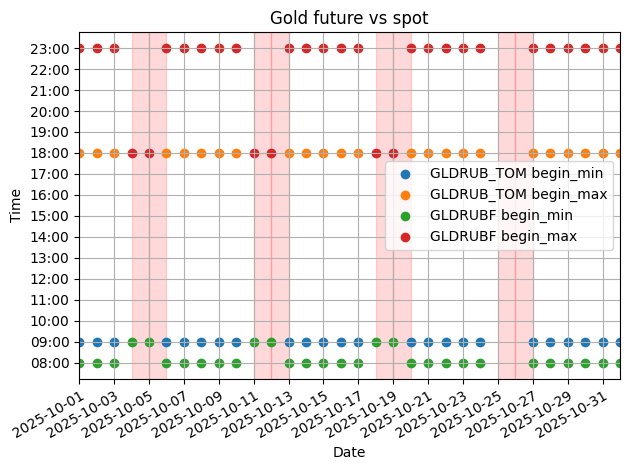

In [232]:
fig, ax = plt.subplots()

ax.scatter(df_gold_last_month_grouped['begin'], df_gold_last_month_grouped['begin_min'], marker='o', label='GLDRUB_TOM begin_min')
ax.scatter(df_gold_last_month_grouped['begin'], df_gold_last_month_grouped['begin_max'], marker='o', label='GLDRUB_TOM begin_max')
ax.scatter(df_gold_future_last_month_grouped['begin'], df_gold_future_last_month_grouped['begin_min'], marker='o', label='GLDRUBF begin_min')
ax.scatter(df_gold_future_last_month_grouped['begin'], df_gold_future_last_month_grouped['begin_max'], marker='o', label='GLDRUBF begin_max')

# Format X axis (dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

# Format Y axis (times)
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))

# Highlight weekends
start = pd.Timestamp('2025-10-01')
end_exclusive = pd.Timestamp('2025-11-01')
for day in pd.date_range(start, end_exclusive, freq='D'):
    if day.weekday() >= 5:  # 5=Sat, 6=Sun
        ax.axvspan(day, day + pd.Timedelta(days=1), color='red', alpha=0.15, zorder=-1)

ax.set_xlim(start, end_exclusive)

for label in ax.get_xticklabels():
    label.set_ha('right')
    label.set_x(-0.05)
    label.set_rotation_mode('anchor')

plt.xticks(rotation=30)
plt.xlabel("Date")
plt.ylabel("Time")
plt.title("Gold future vs spot")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

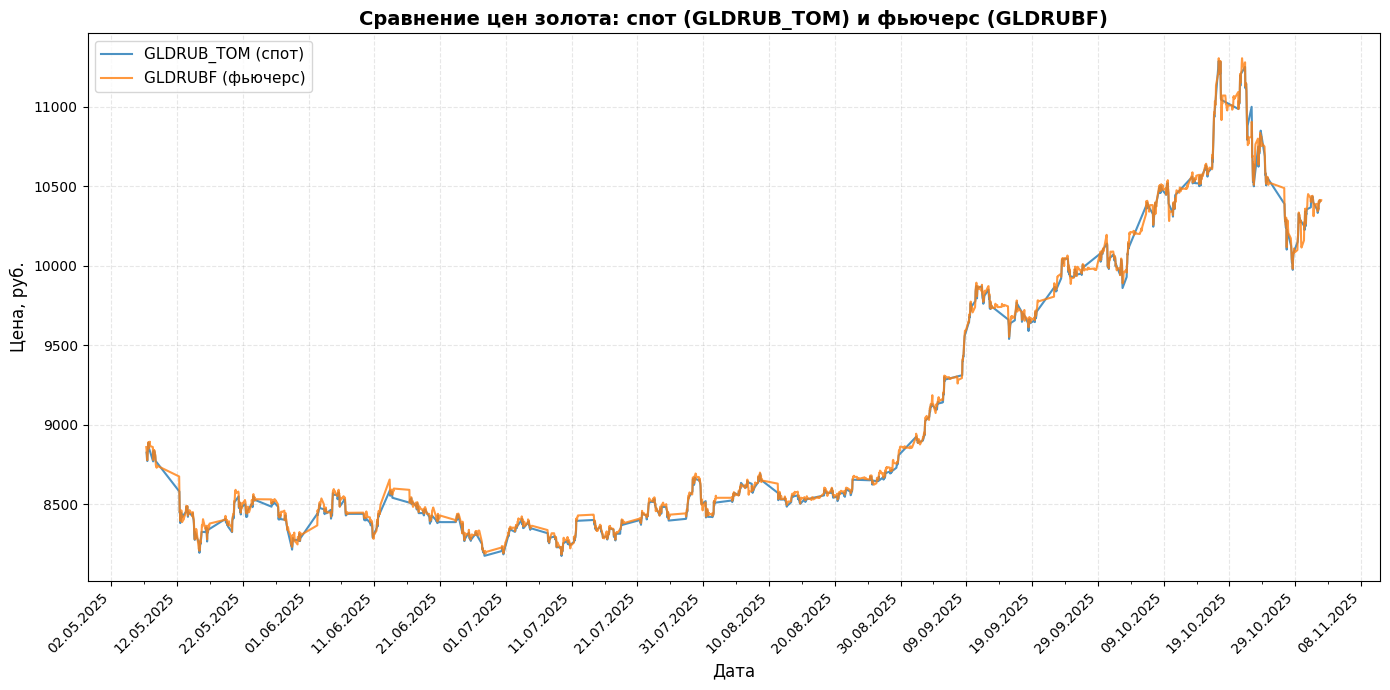

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

# Преобразуем begin в datetime
df_gold['begin'] = pd.to_datetime(df_gold['begin'])
if not df_gold_future.empty:
    df_gold_future['begin'] = pd.to_datetime(df_gold_future['begin'])

# Создаем график
plt.figure(figsize=(14, 7))

# Показываем df_gold если есть данные
if not df_gold.empty:
    df_gold_sorted = df_gold.sort_values('begin')
    plt.plot(df_gold_sorted['begin'], df_gold_sorted['close'], 
             label='GLDRUB_TOM (спот)', alpha=0.8, linewidth=1.5)

# Показываем df_gold_future если есть данные
if not df_gold_future.empty:
    df_gold_future_sorted = df_gold_future.sort_values('begin')
    plt.plot(df_gold_future_sorted['begin'], df_gold_future_sorted['close'], 
             label='GLDRUBF (фьючерс)', alpha=0.8, linewidth=1.5)
else:
    print("\n⚠️ ВНИМАНИЕ: df_gold_future пустой или не содержит данные!")

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена, руб.', fontsize=12)
plt.title('Сравнение цен золота: спот (GLDRUB_TOM) и фьючерс (GLDRUBF)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

ax = plt.gca()
if not df_gold.empty:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=5))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
